# NB15 — Embeddings LLM (Qwen2.5-Coder), analyse (RQ2/RQ3)
### LLM Embeddings (Qwen2.5-Coder) — Analysis (RQ2/RQ3)

**Contexte.** Deuxième angle de la RQ3 (voir la slide "Next Steps") : au lieu de demander
directement au LLM de prédire le verdict (prompting direct, testé séparément), on extrait sa
représentation interne du code (un seul passage forward, pas de génération) et on la fait
passer dans exactement le même protocole d'analyse que TF-IDF/CodeBERT/GraphCodeBERT en RQ2 —
lift k-NN, projection, sonde supervisée. Objectif : est-ce que la représentation d'un LLM
généraliste (pas entraîné spécifiquement pour "comprendre le code"), gelée, contient un signal
comparable ?

---

**Context.** RQ3's second angle (see the "Next Steps" slide): instead of asking the LLM
directly to predict the verdict (direct prompting, tested separately), we extract its internal
representation of the code (a single forward pass, no generation) and run it through exactly
the same RQ2 analysis protocol as TF-IDF/CodeBERT/GraphCodeBERT — k-NN lift, projection,
supervised probe. Goal: does a general-purpose LLM's frozen representation (not trained
specifically to "understand code") carry a comparable signal?

In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EMBEDDINGS_DIR: {EMBEDDINGS_DIR}  (exists={EMBEDDINGS_DIR.exists()})")

STATUS_COLORS = {
    'AC':  '#2ecc71',
    'WA':  '#e74c3c',
    'TLE': '#e67e22',
    'CE':  '#9467bd',
    'RE':  '#3498db',
}
STATUSES_ORDER = ['AC', 'WA', 'TLE', 'CE', 'RE']

PROJECT_ROOT  : /Users/raphael/OJS-submission-analytics
EMBEDDINGS_DIR: /Users/raphael/OJS-submission-analytics/data/processed/embeddings  (exists=True)


## S0 — Génération du corpus
### S0 — Corpus Generation

Mêmes 12 problèmes, même langage (Python), même tirage stratifié (seed=42) que NB11 — seule la
méthode d'embedding change. Commande utilisée (`EMBED_BATCH_SIZE`, variable d'environnement
optionnelle, ajuste le débit) :

```bash
EMBED_BATCH_SIZE=64 python src/embedding.py llm mps Python \
  "p02658,p02718,p02922,p02659,p02623,p02761,p02642,p02714,p02900,p02616,p02574,p02793" \
  100 data/models/Qwen--Qwen2.5-Coder-7B-Instruct
```

**Note sur ce notebook tel quel.** Le `METHOD_TAG` ci-dessous pointe pour l'instant vers un
pilote réduit (n=25/cellule, ~1100 soumissions) — utilisé uniquement pour vérifier que le code
de ce notebook s'exécute correctement de bout en bout, **pas** pour en tirer une conclusion
(échantillon par problème trop petit pour être fiable, même leçon que le prompting direct ce
soir). À repointer vers le run n=100 une fois terminé, avant toute lecture des résultats.

---

Same 12 problems, same language (Python), same stratified draw (seed=42) as NB11 — only the
embedding method changes. Command used (`EMBED_BATCH_SIZE`, optional environment variable,
adjusts throughput):

```bash
EMBED_BATCH_SIZE=64 python src/embedding.py llm mps Python \
  "p02658,p02718,p02922,p02659,p02623,p02761,p02642,p02714,p02900,p02616,p02574,p02793" \
  100 data/models/Qwen--Qwen2.5-Coder-7B-Instruct
```

**Note on this notebook as it stands.** `METHOD_TAG` below currently points to a small pilot
(n=25/cell, ~1100 submissions) — used only to verify this notebook's code runs correctly end to
end, **not** to draw any conclusion from (per-problem sample too small to be reliable, same
lesson as tonight's direct prompting). Repoint to the n=100 run once it finishes, before reading
any results.

In [2]:
METHOD_TAG = "llm_Qwen--Qwen2.5-Coder-7B-Instruct_python_multi12_n25"  # pilote -- repointer vers _multi12 (n=100) une fois pret

emb  = np.load(EMBEDDINGS_DIR / f"embeddings_{METHOD_TAG}.npy")
meta = pl.read_csv(EMBEDDINGS_DIR / f"metadata_{METHOD_TAG}.csv")

assert emb.shape[0] == meta.height, "embeddings et metadata desalignes -- npy et csv ne correspondent pas"

pid_list = sorted(meta["problem_id"].unique().to_list())
print(f"{METHOD_TAG}")
print(f"  {emb.shape[0]:,} soumissions, {emb.shape[1]} dimensions, {len(pid_list)} problemes")
print(f"  verdicts presents : {sorted(meta['status_code'].unique().to_list())}")

llm_Qwen--Qwen2.5-Coder-7B-Instruct_python_multi12_n25
  1,125 soumissions, 3584 dimensions, 12 problemes
  verdicts presents : ['AC', 'RE', 'TLE', 'WA']


## S1 — Criblage quantitatif : lift k-NN par problème
### S1 — Quantitative Screening: k-NN Lift per Problem

Même protocole que NB11 S2 : pour chaque problème, restreint aux soumissions de ce problème
(pas le corpus poolé — la scission entre problèmes domine sinon le signal), k=10 voisins les
plus proches en cosinus, part de voisins partageant le même verdict, comparée à la baseline
Σp² (probabilité d'accord par hasard, pondérée par la vraie distribution des verdicts de ce
problème).

---

Same protocol as NB11 S2: for each problem, restricted to that problem's own submissions (not
the pooled corpus — the between-problem split would otherwise dominate the signal), k=10
nearest neighbors in cosine space, share of neighbors sharing the same verdict, compared
against the Σp² baseline (chance-level agreement, weighted by that problem's real verdict
distribution).

In [3]:
from sklearn.neighbors import NearestNeighbors

K = 10
statuses_all = meta["status_code"].to_numpy()

s1_rows = []
for pid in pid_list:
    idx = np.where((meta["problem_id"] == pid).to_numpy())[0]
    sub_emb = emb[idx]
    sub_labels = statuses_all[idx]

    classes, counts = np.unique(sub_labels, return_counts=True)
    if len(classes) < 2 or len(sub_labels) < K + 1:
        continue
    baseline = float(np.sum((counts / counts.sum()) ** 2))

    nbrs = NearestNeighbors(n_neighbors=K + 1, metric="cosine", algorithm="brute").fit(sub_emb)
    _, nn_idx = nbrs.kneighbors(sub_emb)

    matches, total = 0, 0
    for i in range(len(sub_labels)):
        neigh = nn_idx[i, 1:]  # exclut soi-meme
        matches += int(np.sum(sub_labels[neigh] == sub_labels[i]))
        total += len(neigh)
    consistency = matches / total
    lift = consistency / baseline if baseline > 0 else float("nan")

    s1_rows.append({
        "problem_id": pid, "n": len(sub_labels),
        "baseline": round(baseline, 3), "consistency": round(consistency, 3),
        "lift": round(lift, 3),
    })

df_s1 = pl.DataFrame(s1_rows).sort("lift", descending=True)
print(f"Moyenne du lift sur {df_s1.height} problemes : {df_s1['lift'].mean():.3f}")
df_s1

Moyenne du lift sur 12 problemes : 1.061


problem_id,n,baseline,consistency,lift
str,i64,f64,f64,f64
"""p02658""",100,0.25,0.298,1.192
"""p02659""",82,0.286,0.337,1.176
"""p02623""",100,0.25,0.276,1.104
"""p02616""",100,0.25,0.274,1.096
"""p02761""",78,0.31,0.332,1.072
…,…,…,…,…
"""p02922""",88,0.264,0.278,1.055
"""p02714""",99,0.25,0.251,1.002
"""p02642""",100,0.25,0.249,0.996


## S2 — Projection t-SNE (contrôle visuel)
### S2 — t-SNE Projection (Visual Sanity Check)

Même logique que la slide "Sanity Check"/"The Twist" — projection 2D du problème avec le lift
le plus élevé de S1, colorée par verdict, pour un contrôle visuel avant la sonde.

---

Same logic as the "Sanity Check"/"The Twist" slides — 2D projection of S1's highest-lift
problem, colored by verdict, as a visual check before the probe.

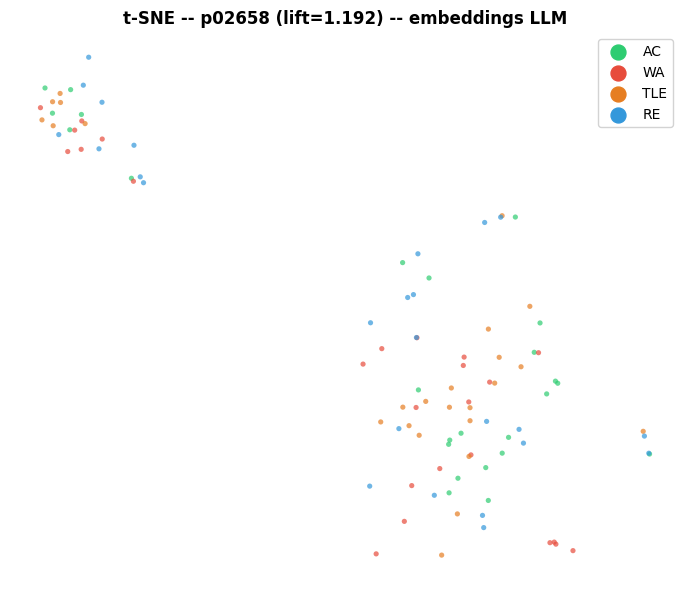

In [4]:
from sklearn.manifold import TSNE

best_pid = df_s1.row(0, named=True)["problem_id"]
idx = np.where((meta["problem_id"] == best_pid).to_numpy())[0]
sub_emb = emb[idx]
sub_labels = statuses_all[idx]

tsne = TSNE(n_components=2, random_state=42, metric="cosine", init="pca",
            perplexity=min(30, len(idx) - 1))
proj = tsne.fit_transform(sub_emb)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(proj[:, 0], proj[:, 1], c=[STATUS_COLORS.get(s, "#aaaaaa") for s in sub_labels],
           s=14, alpha=0.7, linewidths=0)
for v in STATUSES_ORDER:
    if v in sub_labels:
        ax.scatter([], [], c=STATUS_COLORS[v], s=45, label=v)
ax.legend(fontsize=10, markerscale=1.6, framealpha=0.85)
ax.set_title(f"t-SNE -- {best_pid} (lift={df_s1.row(0, named=True)['lift']}) -- embeddings LLM",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## S3 — Sonde supervisée
### S3 — Supervised Probe

Même protocole que NB13 S8 : régression logistique + `StandardScaler`, validation croisée
stratifiée à 5 plis (réduit automatiquement si une classe a moins de 5 exemples), par problème.
Baseline : `DummyClassifier` (classe majoritaire), même validation croisée. Directement
comparable aux 48%/52%/51%/55% déjà établis pour TF-IDF/CodeBERT/GraphCodeBERT/GraphCodeBERT+
graphe.

---

Same protocol as NB13 S8: logistic regression + `StandardScaler`, 5-fold stratified
cross-validation (automatically reduced if a class has fewer than 5 examples), per problem.
Baseline: `DummyClassifier` (majority class), same cross-validation. Directly comparable to the
48%/52%/51%/55% already established for TF-IDF/CodeBERT/GraphCodeBERT/GraphCodeBERT+real
graph.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

s3_rows = []
for pid in pid_list:
    idx = np.where((meta["problem_id"] == pid).to_numpy())[0]
    if len(idx) < 50:
        continue
    sub_emb = emb[idx]
    y = statuses_all[idx]
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2 or counts.min() < 5:
        continue

    n_splits = min(5, counts.min())
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probe_acc = cross_val_score(clf, sub_emb, y, cv=skf, scoring="accuracy").mean()

    dummy = DummyClassifier(strategy="most_frequent")
    dummy_acc = cross_val_score(dummy, sub_emb, y, cv=skf, scoring="accuracy").mean()

    s3_rows.append({
        "problem_id": pid, "n": len(idx),
        "probe_acc": round(probe_acc, 4), "dummy_acc": round(dummy_acc, 4),
        "lift": round(probe_acc - dummy_acc, 4),
    })

df_s3 = pl.DataFrame(s3_rows).sort("lift", descending=True)
print(f"Moyenne probe_acc : {df_s3['probe_acc'].mean():.3f}   Moyenne dummy_acc : {df_s3['dummy_acc'].mean():.3f}")
df_s3

Moyenne probe_acc : 0.373   Moyenne dummy_acc : 0.259


problem_id,n,probe_acc,dummy_acc,lift
str,i64,f64,f64,f64
"""p02659""",82,0.6,0.3051,0.2949
"""p02658""",100,0.51,0.25,0.26
"""p02922""",88,0.4549,0.2843,0.1706
"""p02616""",100,0.38,0.25,0.13
"""p02900""",100,0.34,0.25,0.09
"""p02623""",100,0.33,0.25,0.08
"""p02642""",100,0.29,0.25,0.04
"""p02793""",100,0.29,0.25,0.04
"""p02574""",100,0.28,0.25,0.03


## S4 — Synthèse
### S4 — Synthesis

*(À compléter une fois le run n=100 chargé en S0 — pas de lecture fiable sur le pilote n=25
actuel, cf. note de S0.)*

---

*(To fill in once the n=100 run is loaded in S0 — no reliable reading on the current n=25 pilot,
see S0's note.)*